# Sweep all carbonyl parameters × reaction parameters

### Step 1: Parameter Sweep: Evaluating Carbonyl Descriptors with Multiple ML Models

This cell runs a **parameter sweep over carbonyl descriptors** and tests a series of machine learning regression models.

1. **Load data**
   - Reads the reaction dataset (`dataset_r2filtered_ml.xlsx`) and carbonyl parameters (`carbonyl_parameters.xlsx`).
   - Uses `carbonyl_nr` to join reactions with carbonyl descriptors.

2. **Clean and define target**
   - Ensures key reaction columns (pH, concentrations, `k_obs`) are numeric.
   - Drops rows with missing or non-positive `k_obs`.
   - Defines the target as `lg_k_obs = log10(k_obs)`.

3. **Select descriptors to test**
   - Keeps only numeric carbonyl parameter columns with more than one non-NaN value.
   - Loops over these parameters one by one.

4. **For each carbonyl parameter**
   - Builds a feature matrix: reaction conditions + that single carbonyl parameter.
   - Drops rows with missing values; skips the parameter if < 25 usable rows.
   - Splits into train/test (80/20, `random_state=42`).
   - Standardizes features for models that need scaling.

5. **Train model families**
   For each parameter, it trains:
   - **Linear / regularized**: LinearRegression, RidgeCV, LassoCV, ElasticNetCV, BayesianRidge  
   - **Kernel / neighbors**: LinearSVR, SVR (RBF & poly), KernelRidge, kNN  
   - **Tree ensembles**: RandomForest, GradientBoosting, DecisionTree, ExtraTrees, HistGradientBoosting  
   - **Neural network**: MLPRegressor  
   - **Gaussian process**: GPR with a fixed `C * (RBF + WhiteKernel)` kernel  

   For every model, it:
   - Fits on the training set.
   - Computes R², MAE, RMSE for train and test.
   - Prints a short performance summary.
   - Saves a parity plot (predicted vs. actual `lg_k_obs`) into `plots/<parameter>/`.

6. **Save summary table**
   - Collects all (parameter × model) metrics into a single CSV: `results_all_models_all_parameters.csv`

In [1]:
"""
Parameter sweep over carbonyl descriptors.
For each numeric carbonyl parameter, this script merges the parameter with the reaction dataset,
trains a suite of regression models, saves parity plots, and writes all metrics to
results_all_models_all_parameters.csv.
"""


import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless backend for saving plots
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Linear / Regularized
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, BayesianRidge
# Kernel / Neighbors
from sklearn.svm import SVR, LinearSVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
# Trees / Ensembles
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
# Neural
from sklearn.neural_network import MLPRegressor
# Gaussian Process
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C


# --------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------
RANDOM_STATE = 42
BASE_PLOTS_DIR = "plots"
DATASET_FILE = "dataset_r2filtered_ml.xlsx"
PARAM_FILE = "carbonyl_parameters.xlsx"
SUMMARY_CSV = "results_all_models_all_parameters.csv"
SHOW_PLOTS = False

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})


# --------------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------------
def rmse(y_true, y_pred):
    """Root mean squared error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    """Mean absolute error."""
    return float(mean_absolute_error(y_true, y_pred))

def sanitize(name: str) -> str:
    """Convert an arbitrary string into a safe filename stem."""
    return re.sub(r"[^A-Za-z0-9_]+", "_", name)

def parity_plot_and_save(
    name,
    y_train,
    y_train_pred,
    y_test,
    y_test_pred,
    target_name,
    outdir,
    r2_test,
    mae_test,
):
    """
    Create a parity plot (predicted vs. actual) with a y = x guide line,
    and save it as a transparent PNG.
    """
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    y_all = np.concatenate([y_train, y_test])
    y_min, y_max = float(np.min(y_all)), float(np.max(y_all))

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(y_train, y_train_pred, s=18, alpha=0.7, label="Train")
    ax.scatter(y_test, y_test_pred, s=24, alpha=0.7, label="Test")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.5, label="y = x")
    ax.set_title(f"{name} — R²(test)={r2_test:.3f}, MAE(test)={mae_test:.3f}")
    ax.set_xlabel(f"Actual {target_name}")
    ax.set_ylabel(f"Predicted {target_name}")
    ax.legend()
    plt.tight_layout()

    os.makedirs(outdir, exist_ok=True)
    fig.savefig(
        os.path.join(outdir, f"parity_{sanitize(name)}.png"),
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

def fit_report_plot(name, model, Xtr, Xte, ytr, yte, target_name, outdir):
    """
    Fit a regression model, compute train/test metrics, print a short summary,
    and generate a parity plot.

    Returns
    -------
    dict
        Metrics with keys:
        R2(train), R2(test), MAE(train), MAE(test), RMSE(train), RMSE(test).
    """
    model.fit(Xtr, ytr)
    ytr_pred = model.predict(Xtr)
    yte_pred = model.predict(Xte)

    stats = {
        "R2(train)": r2_score(ytr, ytr_pred),
        "R2(test)": r2_score(yte, yte_pred),
        "MAE(train)": mae(ytr, ytr_pred),
        "MAE(test)": mae(yte, yte_pred),
        "RMSE(train)": rmse(ytr, ytr_pred),
        "RMSE(test)": rmse(yte, yte_pred),
    }

    print(f"[{name}] R2(test)={stats['R2(test)']:.3f}, RMSE(test)={stats['RMSE(test)']:.4f}")

    parity_plot_and_save(
        name,
        ytr,
        ytr_pred,
        yte,
        yte_pred,
        target_name,
        outdir,
        stats["R2(test)"],
        stats["MAE(test)"],
    )
    return stats

# Silence occasional, non-critical GPR linear algebra warnings that can
# arise during kernel optimization on some datasets.
warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")


def run_family(family_name, models_dict, Xtr, Xte, ytr, yte, target_name, outdir, rows, descriptor):
    """
    Run a labeled family of models and collect comparable metrics.

    Appends one row per model to `rows`, including the descriptor name,
    family, model, and all train/test metrics.
    """
    for name, model in models_dict.items():
        stats = fit_report_plot(name, model, Xtr, Xte, ytr, yte, target_name, outdir)
        rows.append({
            "parameter": descriptor,
            "Family": family_name,
            "Model": name,
            "R2(test)": stats["R2(test)"],
            "MAE(test)": stats["MAE(test)"],
            "RMSE(test)": stats["RMSE(test)"],
            "R2(train)": stats["R2(train)"],
            "MAE(train)": stats["MAE(train)"],
            "RMSE(train)": stats["RMSE(train)"],
        })

# --------------------------------------------------------------------
# Data loading and preprocessing
# --------------------------------------------------------------------
df_ds = pd.read_excel(DATASET_FILE)
df_params = pd.read_excel(PARAM_FILE)

reaction_cols_all = ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot", "k_obs"]
for c in reaction_cols_all:
    if c in df_ds.columns:
        df_ds[c] = pd.to_numeric(df_ds[c], errors="coerce")

df_ds = df_ds.dropna(subset=["k_obs"]).copy()
df_ds = df_ds[df_ds["k_obs"] > 0].copy()
df_ds["lg_k_obs"] = np.log10(df_ds["k_obs"])

reaction_cols = [c for c in ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot"] if c in df_ds.columns]

join_key = "carbonyl_nr"

for c in df_params.columns:
    if c != join_key:
        df_params[c] = pd.to_numeric(df_params[c], errors="coerce")

param_cols = [
    c for c in df_params.columns
    if c != join_key
    and pd.api.types.is_numeric_dtype(df_params[c])
    and df_params[c].notna().sum() > 1  # avoid degenerate all-NaN or single-valued columns
]

# --------------------------------------------------------------------
# Parameter sweep and model benchmarking
# --------------------------------------------------------------------
out_rows = []

for param in param_cols:
    sub_params = df_params[[join_key, param]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feat_cols = [c for c in reaction_cols if c in merged.columns] + [param]
    merged = merged.dropna(subset=feat_cols + ["lg_k_obs"]).copy()

    if merged.shape[0] < 25:
        print(f"Skipping param '{param}' (only {merged.shape[0]} usable rows)")
        continue

    X = merged[feat_cols].values
    y = merged["lg_k_obs"].values
    target_name = "lg_k_obs"

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )

    scaler = StandardScaler().fit(X_train)
    X_train_std = scaler.transform(X_train)
    X_test_std = scaler.transform(X_test)

    PLOTS_DIR = os.path.join(BASE_PLOTS_DIR, sanitize(param))

    # --- Linear / Regularized (scaled) ---
    linear_models = {
        "Linear Regression": LinearRegression(),
        "RidgeCV": RidgeCV(alphas=np.logspace(-6, 6, 25)),
        "LassoCV": LassoCV(alphas=np.logspace(-6, 1, 30), max_iter=20000, random_state=RANDOM_STATE),
        "ElasticNetCV": ElasticNetCV(
            l1_ratio=np.linspace(0.05, 0.95, 10),
            alphas=np.logspace(-6, 1, 30),
            max_iter=20000,
            random_state=RANDOM_STATE,
        ),
        "BayesianRidge": BayesianRidge(),
    }
    run_family(
        "Linear/Regularized",
        linear_models,
        X_train_std,
        X_test_std,
        y_train,
        y_test,
        target_name,
        PLOTS_DIR,
        out_rows,
        param,
    )

    # --- Kernel / Neighbors (scaled) ---
    kernel_models = {
        "LinearSVR": LinearSVR(random_state=RANDOM_STATE, max_iter=20000, epsilon=0.1, C=1.0),
        "SVR_RBF": SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"),
        "SVR_Poly3": SVR(kernel="poly", degree=3, C=1.0, epsilon=0.1, gamma="scale"),
        "KernelRidge(RBF,alpha=1e-1)": KernelRidge(kernel="rbf", alpha=1e-1, gamma=None),
        "kNN(k=5,dist)": KNeighborsRegressor(n_neighbors=5, weights="distance"),
    }
    run_family(
        "Kernel/Neighbors",
        kernel_models,
        X_train_std,
        X_test_std,
        y_train,
        y_test,
        target_name,
        PLOTS_DIR,
        out_rows,
        param,
    )

    # --- Tree Ensembles (unscaled) ---
    tree_models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=600,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    }
    run_family(
        "Tree Ensembles",
        tree_models,
        X_train,
        X_test,
        y_train,
        y_test,
        target_name,
        PLOTS_DIR,
        out_rows,
        param,
    )

    # --- Neural (scaled) ---
    mlp_models = {
        "MLP(100)": MLPRegressor(
            hidden_layer_sizes=(100,),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate="adaptive",
            max_iter=5000,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    }
    run_family(
        "Neural",
        mlp_models,
        X_train_std,
        X_test_std,
        y_train,
        y_test,
        target_name,
        PLOTS_DIR,
        out_rows,
        param,
    )

    # --- Gaussian Process (scaled) ---
    gpr_kernels = {
        "GPR_C*(RBF+White)_fixed":
            C(1.0, constant_value_bounds="fixed") * (
                RBF(length_scale=1.0, length_scale_bounds="fixed") +
                WhiteKernel(noise_level=1e-2, noise_level_bounds="fixed")
            )
    }

    for name, ker in gpr_kernels.items():
        gpr = GaussianProcessRegressor(
            kernel=ker,
            normalize_y=True,
            random_state=RANDOM_STATE,
            n_restarts_optimizer=0,
        )
        gpr.fit(X_train_std, y_train)
        ytr_pred = gpr.predict(X_train_std)
        yte_pred = gpr.predict(X_test_std)

        stats = {
            "parameter": param,
            "R2(train)": r2_score(y_train, ytr_pred),
            "R2(test)": r2_score(y_test, yte_pred),
            "MAE(train)": mae(y_train, ytr_pred),
            "MAE(test)": mae(y_test, yte_pred),
            "RMSE(train)": rmse(y_train, ytr_pred),
            "RMSE(test)": rmse(y_test, yte_pred),
            "Kernel(final)": str(gpr.kernel_),
        }

        print(
            f"[{name}] R2(test)={stats['R2(test)']:.3f}, "
            f"RMSE(test)={stats['RMSE(test)']:.4f} (kernel → {stats['Kernel(final)']})"
        )

        parity_plot_and_save(
            name,
            y_train,
            ytr_pred,
            y_test,
            yte_pred,
            target_name,
            PLOTS_DIR,
            stats["R2(test)"],
            stats["MAE(test)"],
        )

        out_rows.append({
            "parameter": param,
            "Family": "Gaussian Process",
            "Model": name,
            "R2(test)": stats["R2(test)"],
            "MAE(test)": stats["MAE(test)"],
            "RMSE(test)": stats["RMSE(test)"],
            "R2(train)": stats["R2(train)"],
            "MAE(train)": stats["MAE(train)"],
            "RMSE(train)": stats["RMSE(train)"],
        })


# --------------------------------------------------------------------
# Save consolidated metrics
# --------------------------------------------------------------------
combined = pd.DataFrame(out_rows)
combined.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved: {SUMMARY_CSV} and parity plots under '{BASE_PLOTS_DIR}/<parameter>/'")

[Linear Regression] R2(test)=0.294, RMSE(test)=1.0030
[RidgeCV] R2(test)=0.294, RMSE(test)=1.0030
[LassoCV] R2(test)=0.294, RMSE(test)=1.0030
[ElasticNetCV] R2(test)=0.294, RMSE(test)=1.0030
[BayesianRidge] R2(test)=0.294, RMSE(test)=1.0029
[LinearSVR] R2(test)=0.267, RMSE(test)=1.0223
[SVR_RBF] R2(test)=0.962, RMSE(test)=0.2316
[SVR_Poly3] R2(test)=0.543, RMSE(test)=0.8070
[KernelRidge(RBF,alpha=1e-1)] R2(test)=0.968, RMSE(test)=0.2122
[kNN(k=5,dist)] R2(test)=0.951, RMSE(test)=0.2647
[RandomForest] R2(test)=0.993, RMSE(test)=0.0991
[GradientBoosting] R2(test)=0.972, RMSE(test)=0.2013
[DecisionTree] R2(test)=0.989, RMSE(test)=0.1256
[ExtraTrees] R2(test)=0.994, RMSE(test)=0.0939
[HistGradientBoosting] R2(test)=0.991, RMSE(test)=0.1104
[MLP(100)] R2(test)=0.969, RMSE(test)=0.2093
[GPR_C*(RBF+White)_fixed] R2(test)=0.976, RMSE(test)=0.1841 (kernel → 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.01))
[Linear Regression] R2(test)=0.299, RMSE(test)=0.9995
[RidgeCV] R2(test)=0.299,

### Step 2: Summary of descriptor and model performance

This cell loads the combined sweep results from `results_all_models_all_parameters.csv`,
computes the median test R² for each (model, descriptor) pair, and provides three global
summaries:

1. Prints a table with the **best descriptor per model**  
   (sorted by decreasing median R²(test)).

2. Generates and displays a **heatmap of median R²(test)** for all descriptor–model combinations,  
   ordered by overall performance, and saves it as  
   `plots/heatmap_medianR2_descriptor_by_model.png`.

3. Generates and displays a **boxplot of R²(test) per model** across all descriptors,  
   showing the distribution of model performance independent of descriptor choice.  
   The figure is saved as  
   `plots/boxplot_R2_per_model.png`.

Best descriptor per model (by median R²(test)):


,Model,Descriptor,median_R2
3,ExtraTrees,homo_boltz,0.993840
12,RandomForest,hirsh_qcm5h_boltz,0.993225
6,HistGradientBoosting,lumo_boltz,0.991802
1,DecisionTree,nbo_min,0.989088
4,GPR_C*(RBF+White)_fixed,dg_ch3,0.979566
5,GradientBoosting,lumo_boltz,0.972318
11,MLP(100),dg_ch3,0.971864
7,"KernelRidge(RBF,alpha=1e-1)",dg_ch3,0.971417
15,SVR_RBF,dg_ch3,0.968356
16,"kNN(k=5,dist)",nbo_boltz,0.960445


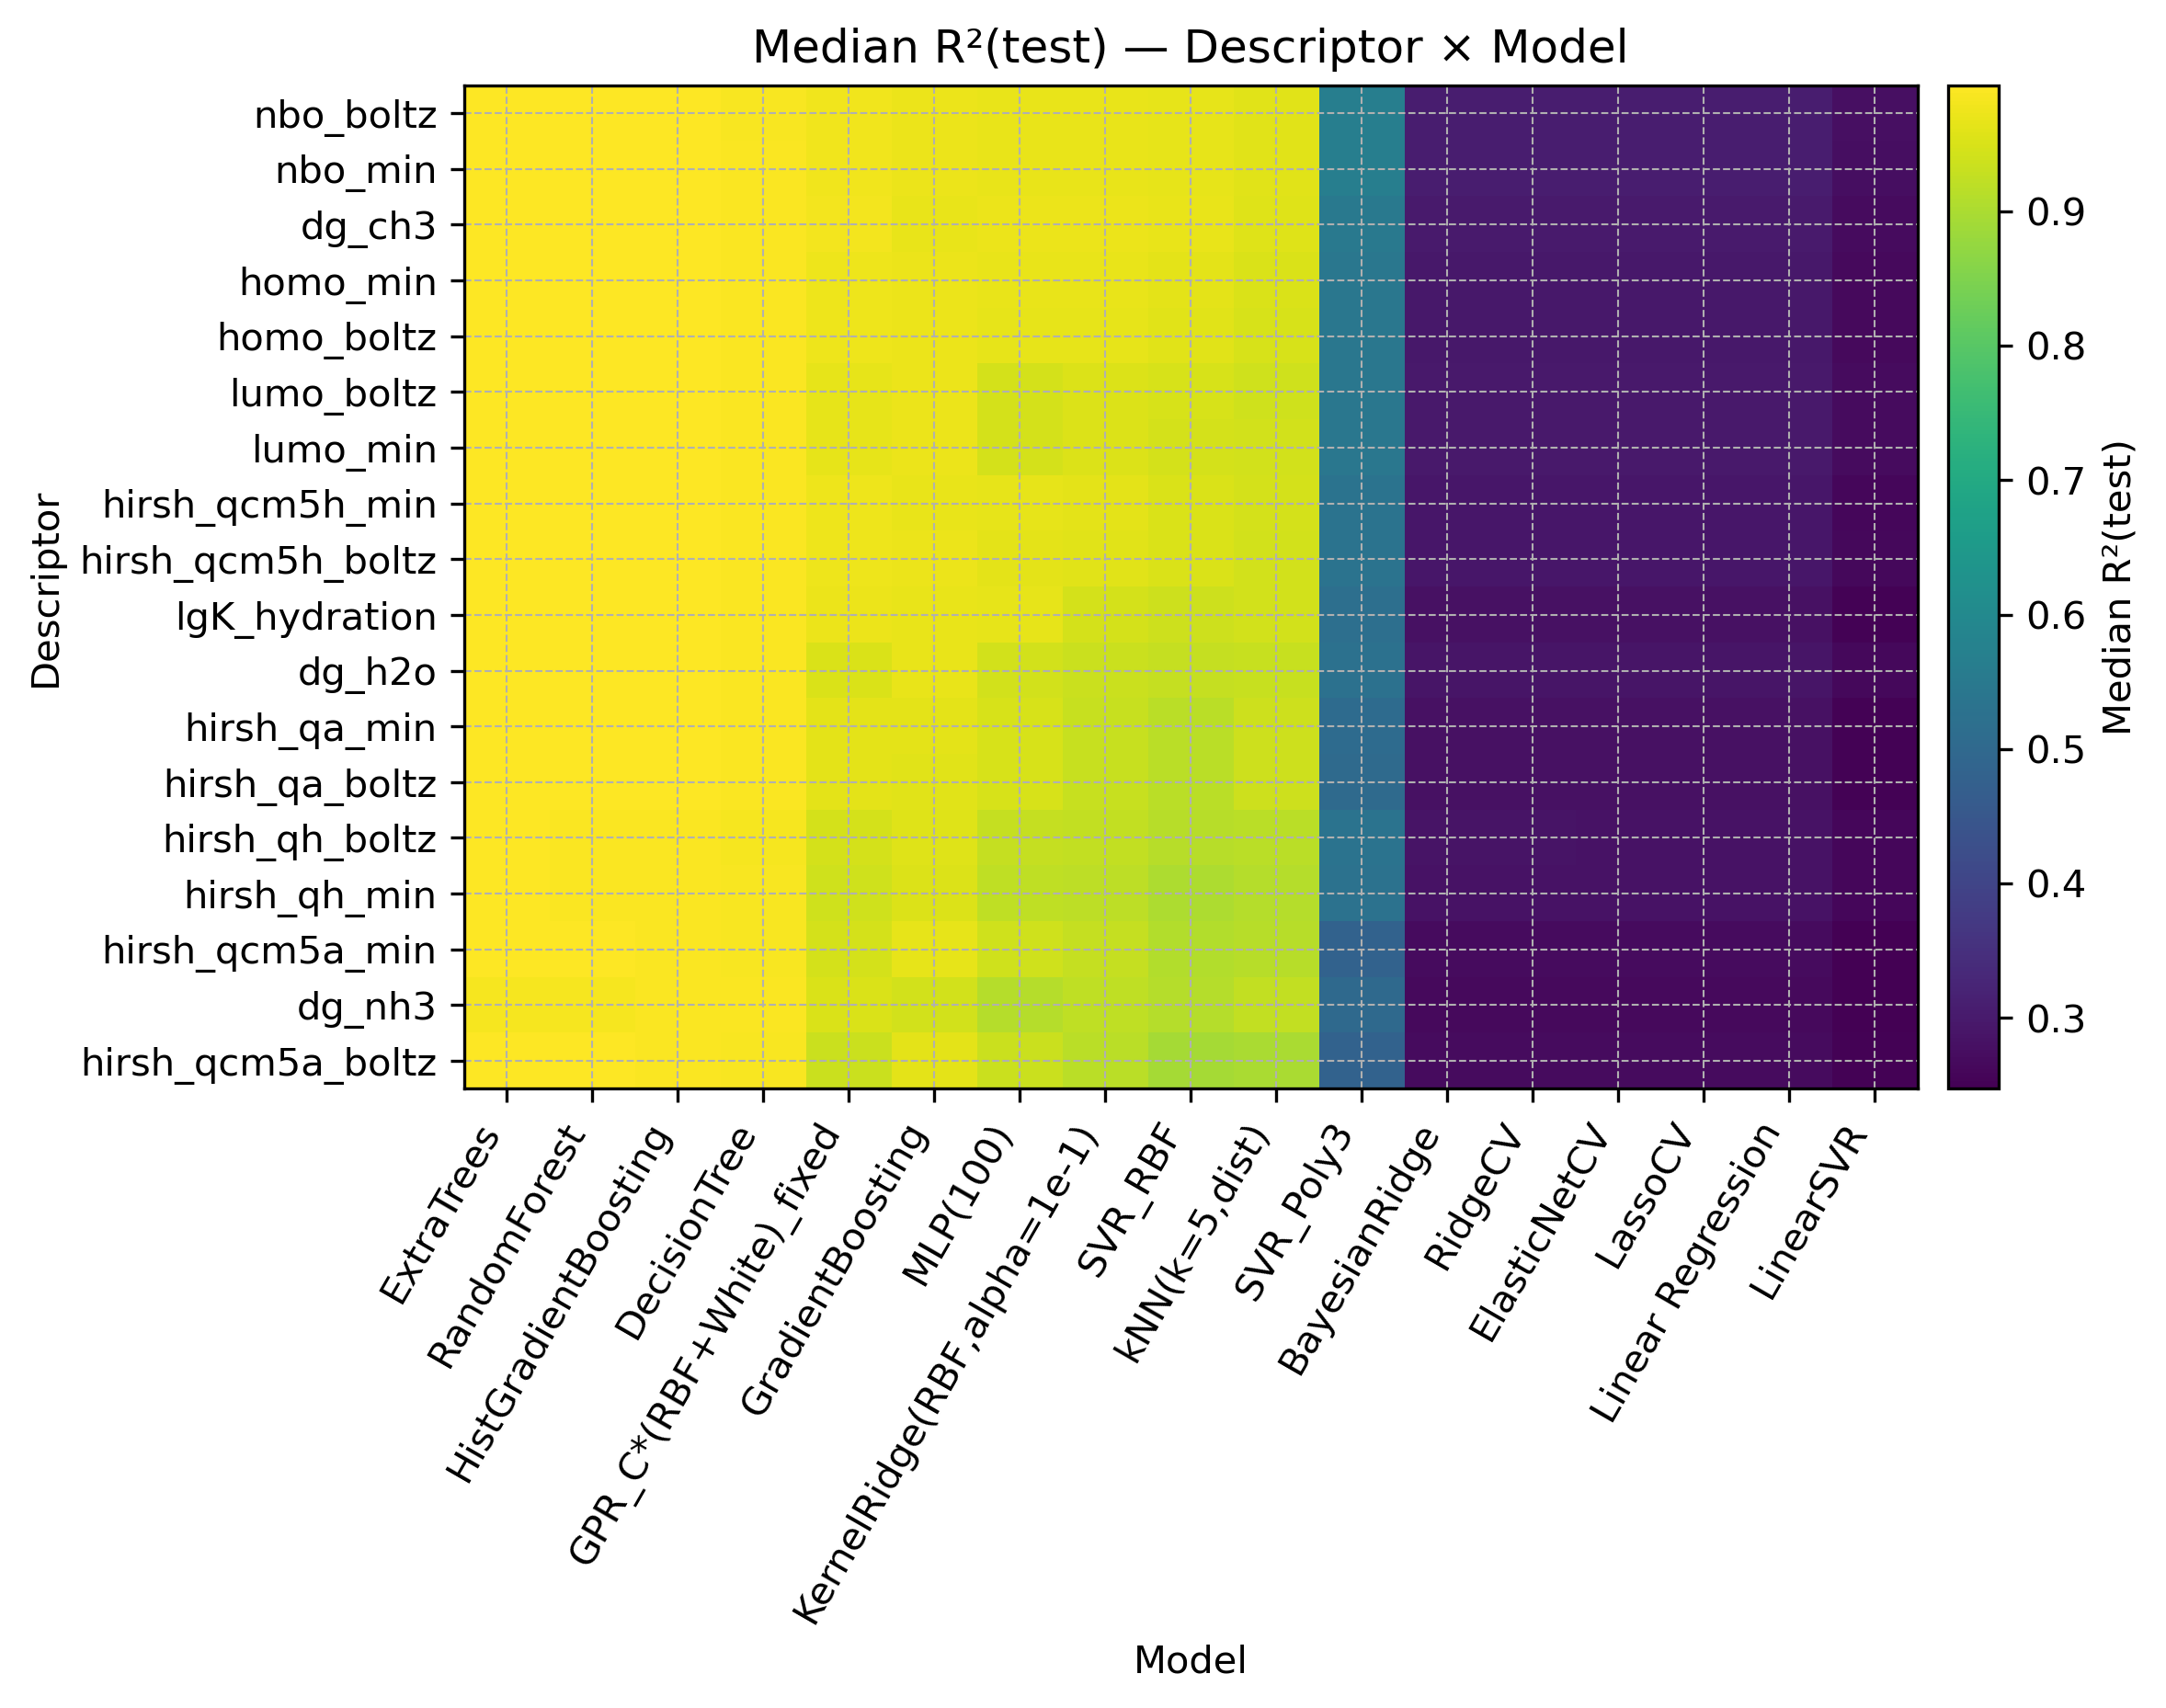

Saved heatmap to: /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/train_test/plots/heatmap_medianR2_descriptor_by_model.png


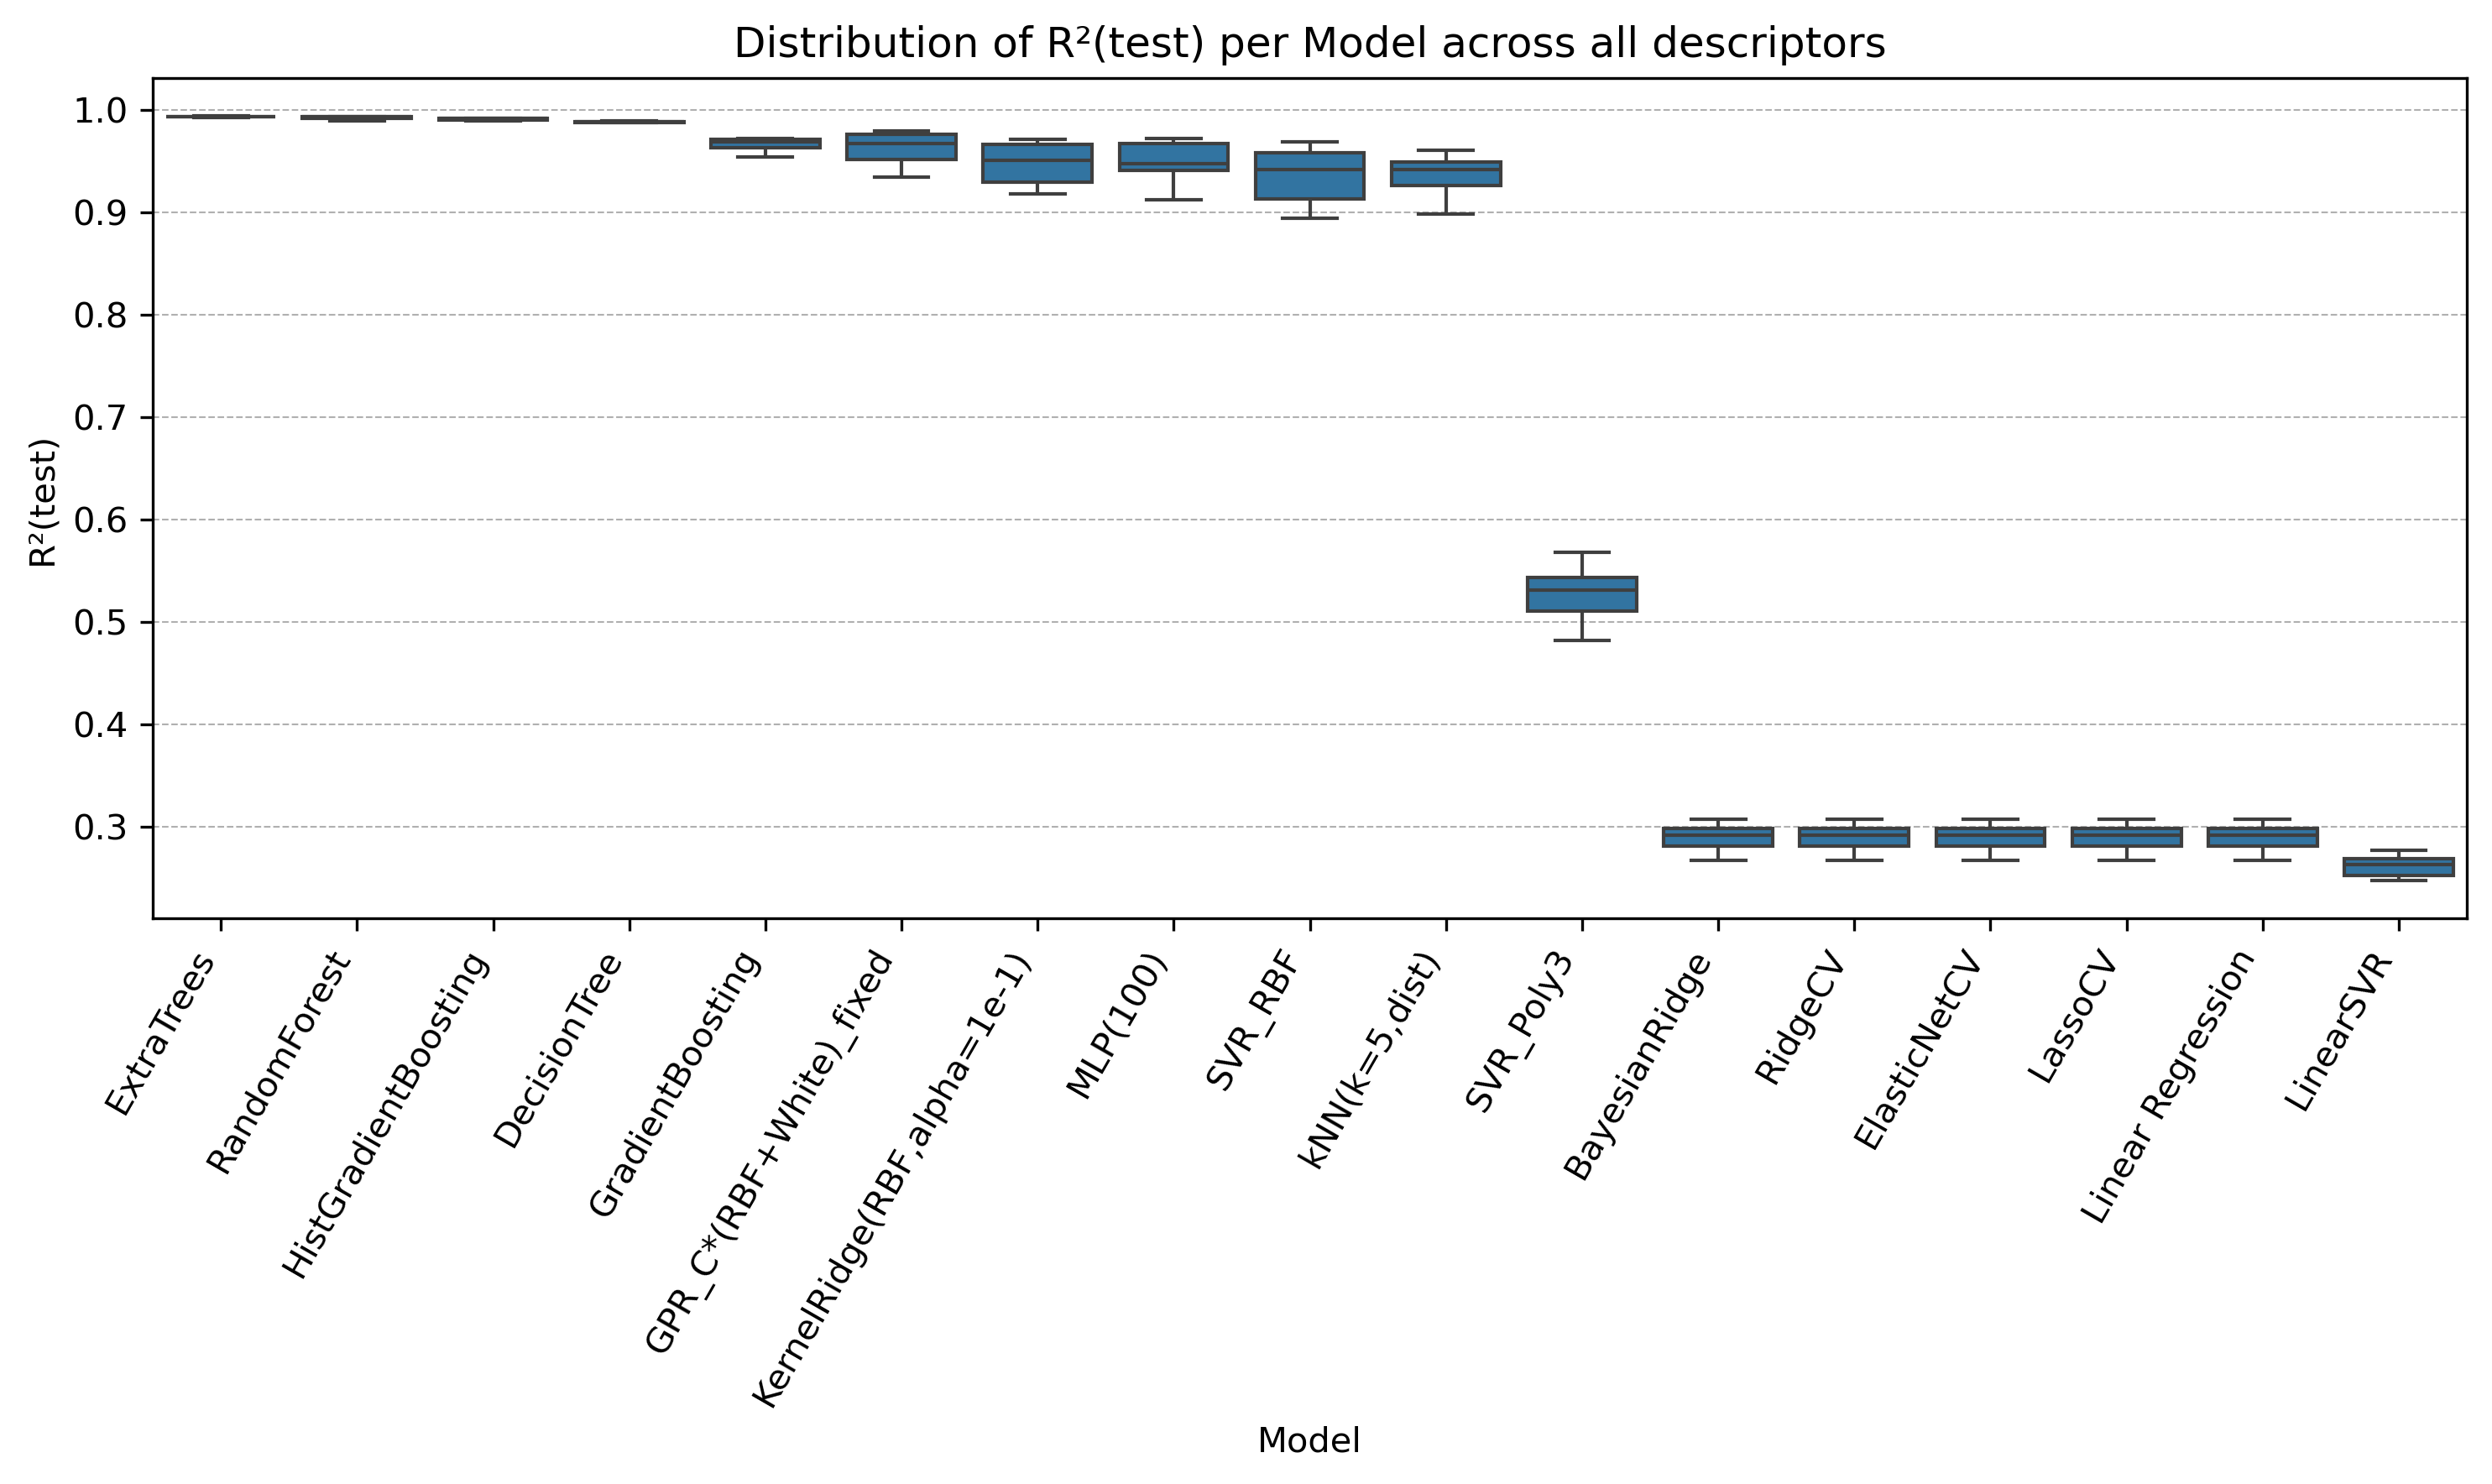

Saved boxplot to: /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/train_test/plots/boxplot_R2_per_model.png


In [4]:
from pathlib import Path
from IPython.display import display, Image
import seaborn as sns

# --------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------
plt.rcParams.update({"figure.dpi": 140})
VIZ_DIR = Path("plots")
VIZ_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_CSV = "results_all_models_all_parameters.csv"
HEATMAP_FILE = VIZ_DIR / "heatmap_medianR2_descriptor_by_model.png"
BOXPLOT_FILE = VIZ_DIR / "boxplot_R2_per_model.png"

# --------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------
def load_results(path: str = RESULTS_CSV) -> pd.DataFrame:
    """
    Load the sweep results and ensure a 'Descriptor' column is present.
    Accepts 'parameter', 'Descriptor', or 'Parameter' from upstream code.
    """
    df = pd.read_csv(path)
    # strip whitespace from column names
    df = df.rename(columns={c: c.strip() for c in df.columns})

    for cand in ["Descriptor", "parameter", "Parameter"]:
        if cand in df.columns:
            df = df.rename(columns={cand: "Descriptor"})
            break

    if "Descriptor" not in df.columns:
        raise ValueError(
            "No descriptor column found (expected 'parameter', 'Parameter', or 'Descriptor')."
        )
    return df

# --------------------------------------------------------------------
# Load data and summarize
# --------------------------------------------------------------------
df_all = load_results()

# Median R²(test) per (Model, Descriptor)
md = (
    df_all.groupby(["Model", "Descriptor"], as_index=False)["R2(test)"]
          .median()
          .rename(columns={"R2(test)": "median_R2"})
)

# Best descriptor for each model (by median R²)
best_desc_per_model = (
    md.sort_values(["Model", "median_R2"], ascending=[True, False])
      .groupby("Model", as_index=False)
      .first()
      .sort_values("median_R2", ascending=False)
)

print("Best descriptor per model (by median R²(test)):")
display(best_desc_per_model)

# --------------------------------------------------------------------
# Heatmap: Descriptor × Model of median R²(test)
# --------------------------------------------------------------------
pivot_desc_model = md.pivot(index="Descriptor", columns="Model", values="median_R2")

# Order models by their best descriptor; descriptors by mean performance
model_order = pivot_desc_model.max(axis=0).sort_values(ascending=False).index.tolist()
desc_order = pivot_desc_model.mean(axis=1).sort_values(ascending=False).index.tolist()

heat = pivot_desc_model.loc[desc_order, model_order]

fig_w = max(8, 0.45 * heat.shape[1])
fig_h = max(6, 0.35 * heat.shape[0])
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(heat.values, aspect="auto", interpolation="nearest")
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=60, ha="right")
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)

ax.set_title("Median R²(test) — Descriptor × Model")
ax.set_xlabel("Model")
ax.set_ylabel("Descriptor")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Median R²(test)")

plt.tight_layout()
fig.savefig(HEATMAP_FILE, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)

display(Image(filename=str(HEATMAP_FILE)))
print(f"Saved heatmap to: {HEATMAP_FILE.resolve()}")

# --------------------------------------------------------------------
# Boxplot: distribution of R²(test) per model across all descriptors
# --------------------------------------------------------------------
model_order_box = (
    df_all.groupby("Model")["R2(test)"]
          .median()
          .sort_values(ascending=False)
          .index
          .tolist()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_all,
    x="Model",
    y="R2(test)",
    order=model_order_box,
    showfliers=False,
    ax=ax,
)
plt.xticks(rotation=60, ha="right")
ax.set_title("Distribution of R²(test) per Model across all descriptors")
ax.set_xlabel("Model")
ax.set_ylabel("R²(test)")
plt.tight_layout()

fig.savefig(BOXPLOT_FILE, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)

display(Image(filename=str(BOXPLOT_FILE)))
print(f"Saved boxplot to: {BOXPLOT_FILE.resolve()}")
